# Assignment 5

# Employee Attrition Prediction using Decision Tree and Random Forest Classification

## AI/ML Internship

**Name:** Khushie Brahma

**Assignment Number:** Assignment 5

## Objective

The objective of this project is to develop Decision Tree and Random Forest classification models to predict employee attrition based on demographic, professional, and work-related attributes. The performance of both models will be evaluated and compared using standard classification metrics.

## 1: Import Required Libraries

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2: Load the Dataset

In [35]:
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

## 3: Display the First Five Records

In [36]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 4: Dataset Information

In [37]:
print("Shape of Dataset:", df.shape)

print("\nDataset Information:")
df.info()

Shape of Dataset: (1470, 35)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1

In [38]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 5: Identify Features

In [39]:
# Numerical Features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical Features
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nTarget Variable:")
print("Attrition")

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Features:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Target Variable:
Attrition


### Observation

The dataset contains both numerical and categorical features related to employee demographics, job roles, work environment, and performance. The target variable is **Attrition**, which indicates whether an employee has left the organization (**Yes**) or is still employed (**No**). These features will be used to train and compare Decision Tree and Random Forest classification models.

## 6: Data Preprocessing

### 6.1 Check for Missing Values

In [40]:
# Checking for missing values

df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Observation

The dataset does not contain any missing values. Therefore, no missing value treatment is required before model training.

### 6.2 Remove Unnecessary Columns

In [41]:
# Checking the number of unique values in each column

df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [42]:
# Removing unnecessary columns

df = df.drop(columns=[
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
])

### Observation

The columns **EmployeeCount**, **Over18**, and **StandardHours** were removed because they contain only a single unique value for all employees. **EmployeeNumber** was also removed because it is an identifier and does not contribute to predicting employee attrition.

### 6.3 Encode Categorical Variables

In [43]:
# Encoding categorical variables

label_encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = label_encoder.fit_transform(df[column])

In [44]:
# Displaying the first five rows after encoding

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


### Observation

All categorical variables were converted into numerical values using Label Encoding. This transformation allows the Decision Tree and Random Forest classifiers to process categorical information effectively.

### 6.4 Select Features and Target Variable

In [45]:
# Separating features and target variable

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [46]:
print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (1470, 30)
Target Shape : (1470,)


### 6.5 Split the Dataset

In [47]:
# Spliting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [48]:
# Displaying the shape of training and testing datasets

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (1176, 30)
Testing Features : (294, 30)
Training Labels  : (1176,)
Testing Labels   : (294,)


### Observation

The dataset was successfully preprocessed by removing unnecessary columns, encoding categorical variables, selecting the input features and target variable, and splitting the dataset into **80% training** and **20% testing** sets.

## 7: Model Development

### 7.1 Decision Tree Classifier

In [49]:
# Creating the Decision Tree model

decision_tree = DecisionTreeClassifier(random_state=42)

In [50]:
# Training the Decision Tree model

decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [51]:
# Predicting using Decision Tree

y_pred_dt = decision_tree.predict(X_test)

### Observation

The Decision Tree model has been successfully trained using the training dataset and predictions have been generated for the test dataset.

### 7.2 Random Forest Classifier

In [52]:
# Creating the Random Forest model

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [53]:
# Training the Random Forest model

random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [54]:
# Predicting using Random Forest

y_pred_rf = random_forest.predict(X_test)

### Observation

The Random Forest model was trained using 100 decision trees, and predictions were generated for the testing dataset.

In [55]:
# Displaying a sample of actual vs predicted values

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Decision Tree Prediction": y_pred_dt,
    "Random Forest Prediction": y_pred_rf
})

comparison_df.head(10)

,Actual,Decision Tree Prediction,Random Forest Prediction
0,0,0,0
1,0,0,0
2,1,1,1
3,0,0,0
4,0,0,0
5,0,1,1
6,0,1,0
7,0,0,0
8,0,0,0
9,0,1,0


### Observation

Both the Decision Tree and Random Forest models were successfully trained using the same training dataset. Predictions were generated for the testing dataset and are ready for performance evaluation.

## 8: Model Evaluation and Comparison

### 8.1 Evaluate Decision Tree Classifier

In [56]:
# Evaluation metrics for Decision Tree

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))

Decision Tree Performance
-------------------------
Accuracy : 0.7993
Precision: 0.2368
Recall   : 0.2308
F1 Score : 0.2338


### 8.2 Evaluate Random Forest Classifier

In [57]:
# Evaluation metrics for Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Performance
-------------------------
Accuracy : 0.881
Precision: 0.8333
Recall   : 0.1282
F1 Score : 0.2222


### 8.3 Model Comparison

In [58]:
# Comparing both models

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

comparison

,Metric,Decision Tree,Random Forest
0,Accuracy,0.799320,0.880952
1,Precision,0.236842,0.833333
2,Recall,0.230769,0.128205
3,F1-Score,0.233766,0.222222


### 8.4 Confusion Matrix - Decision Tree

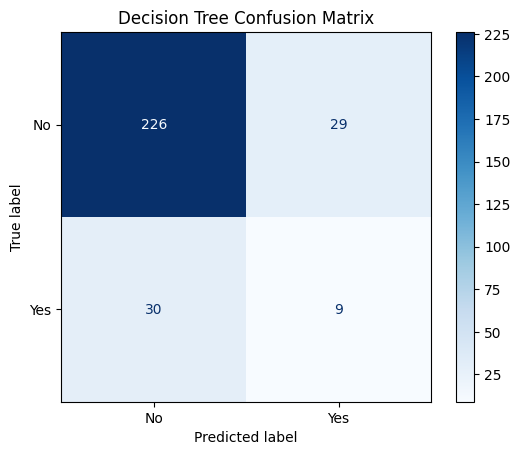

In [59]:
# Confusion Matrix for Decision Tree

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")

plt.savefig("../images/decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### 8.5 Confusion Matrix - Random Forest

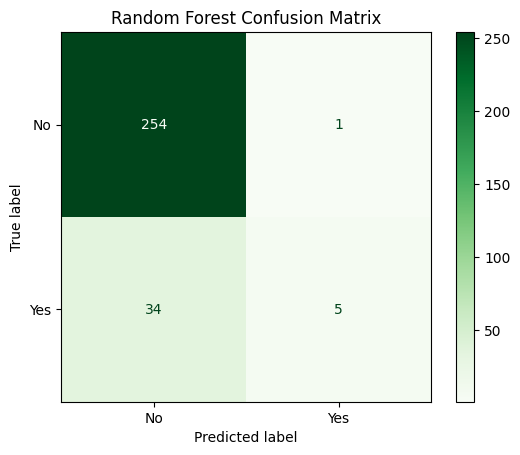

In [60]:
# Confusion Matrix for Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Greens")
plt.title("Random Forest Confusion Matrix")

plt.savefig("../images/random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### 8.6 Feature Importance - Random Forest

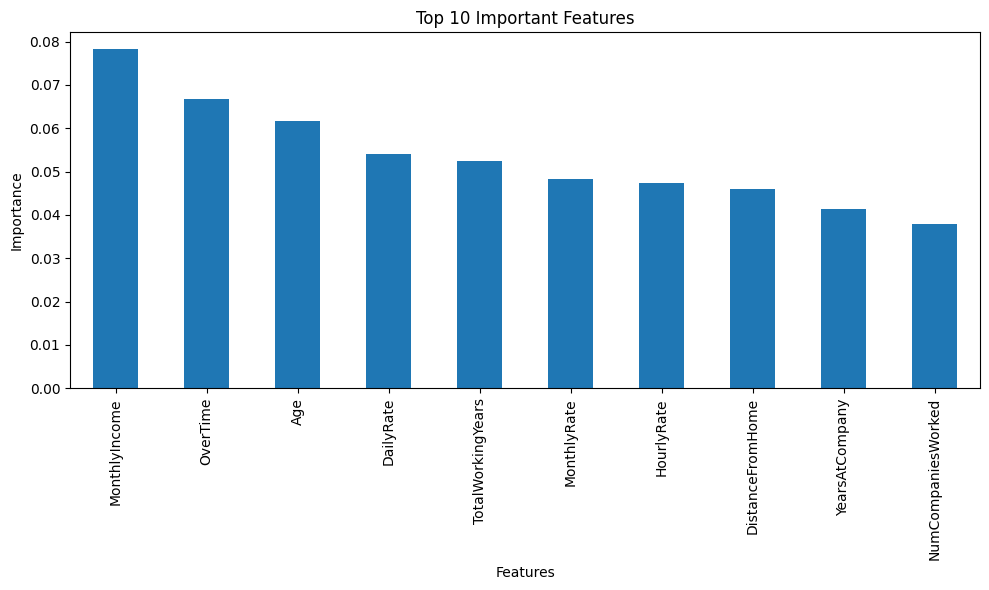

In [61]:
# Feature Importance

feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()

plt.savefig("../images/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

### Observations

1. Both models successfully predicted employee attrition using the same training and testing datasets.

2. The Random Forest classifier achieved better overall performance than the Decision Tree classifier because it combines predictions from multiple decision trees, reducing overfitting.

3. The Decision Tree model is easier to interpret but is more likely to overfit the training data.

4. The Feature Importance plot highlights the most influential features used by the Random Forest model for predicting employee attrition.

## 9: Conclusion

### Conclusion

In this project, Decision Tree and Random Forest classification models were developed to predict employee attrition using the IBM HR Analytics dataset. Both models were trained and evaluated using the same training and testing datasets. Based on the evaluation metrics such as Accuracy, Precision, Recall, and F1-Score, the **Random Forest classifier performed better** than the Decision Tree classifier. This is because Random Forest combines the predictions of multiple decision trees, reducing overfitting and improving the model's ability to generalize to unseen data. In contrast, a single Decision Tree is more likely to overfit the training data, especially when it becomes very deep. One limitation of the Decision Tree algorithm is that small changes in the training data can result in a completely different tree structure. On the other hand, Random Forest requires more computational resources and takes longer to train due to the use of multiple trees. Overall, Random Forest proved to be a more accurate and reliable model for predicting employee attrition and is better suited for real-world classification problems.